In [1]:
!pip install shap -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import shap
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(
    "../data/processed/final_featured_sales.csv"
)

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,...,Lag_12,Rolling_Mean_4,Rolling_Std_4,Moving_Average_8,Festival_Trend,Festival_Sentiment,Trend_Engagement,Sales_Growth,Store_Avg_Sales,Store_Sales_Rank
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,...,1643690.9,1576836.025,112353.415114,1522329.76,0.00,0.000,192.7680,-0.001055,1.555264e+06,5220.0
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,...,1643690.9,1576836.025,112353.415114,1522329.76,336.12,1.350,668.3186,-0.001055,1.555264e+06,5220.0
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,...,1643690.9,1576836.025,112353.415114,1522329.76,356.94,5.964,682.3503,-0.018264,1.555264e+06,5220.0
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,...,1643690.9,1576836.025,112353.415114,1522329.76,569.76,6.544,1121.0028,-0.125462,1.555264e+06,5220.0
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,...,1643690.9,1554614.970,103135.002548,1522329.76,514.24,5.056,923.7036,0.102913,1.555264e+06,5220.0


Data Preparation

In [4]:
df = pd.get_dummies(
    df,
    columns=["Festival_Name"],
    drop_first=True
)

df.drop(
    columns=["Date"],
    inplace=True
)

Create X and y

In [5]:
TARGET = "Weekly_Sales"

X = df.drop(
    columns=[TARGET]
)

y = df[TARGET]

print(X.shape)

(6435, 52)


Load Best Model

In [6]:
best_model = joblib.load(
    "../models/best_model.pkl"
)

print(best_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)


Create SHAP Explainer

In [7]:
explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    X
)

SHAP Summary Plot

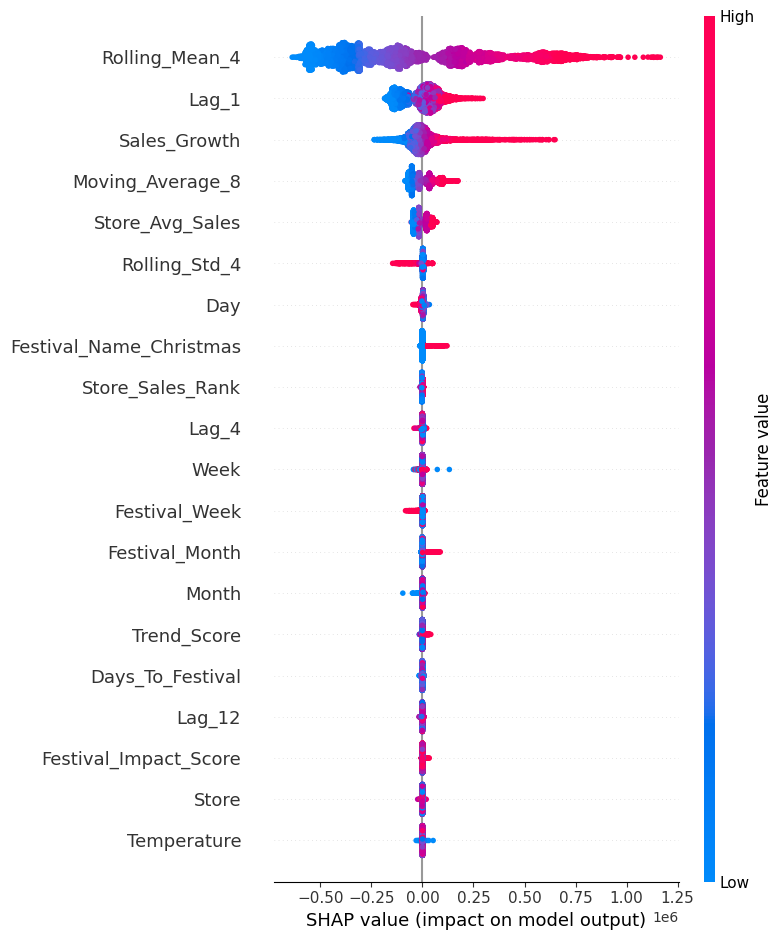

In [8]:
shap.summary_plot(
    shap_values,
    X
)

SHAP Bar Plot

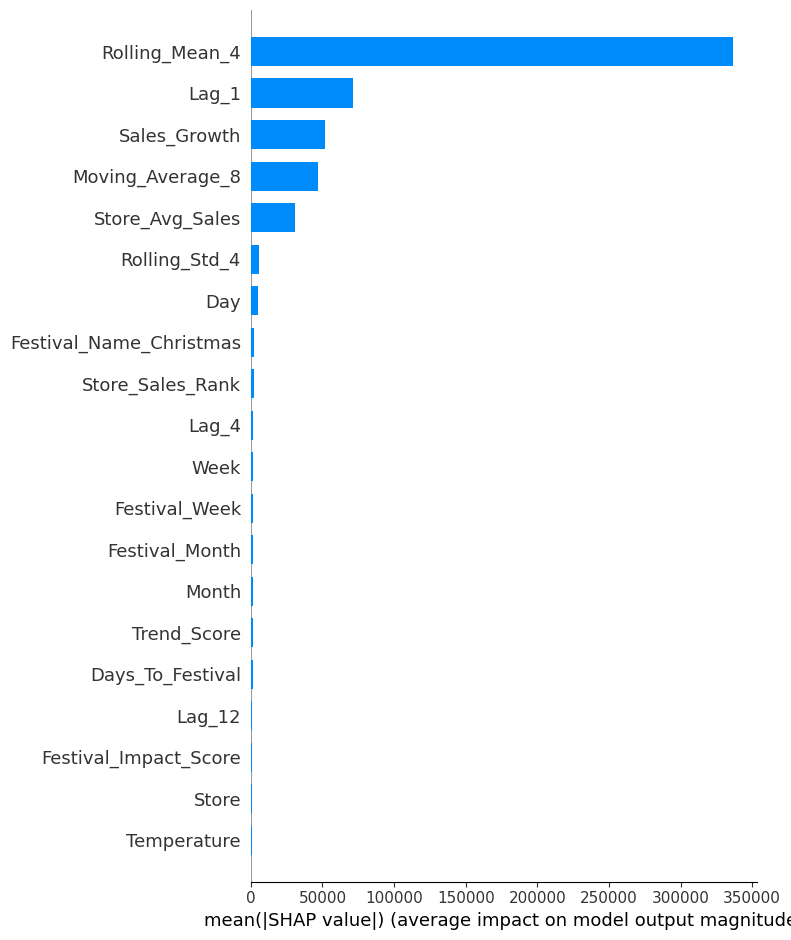

In [9]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

Top 20 Important Features

In [10]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    np.abs(
        shap_values
    ).mean(axis=0)

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
30,Rolling_Mean_4,336698.843750
27,Lag_1,71234.218750
36,Sales_Growth,51929.601562
32,Moving_Average_8,47190.742188
37,Store_Avg_Sales,30580.281250
31,Rolling_Std_4,5708.929688
10,Day,4784.191895
39,Festival_Name_Christmas,2532.345459
38,Store_Sales_Rank,2220.090088
28,Lag_4,1770.846924


Feature Importance Visualization

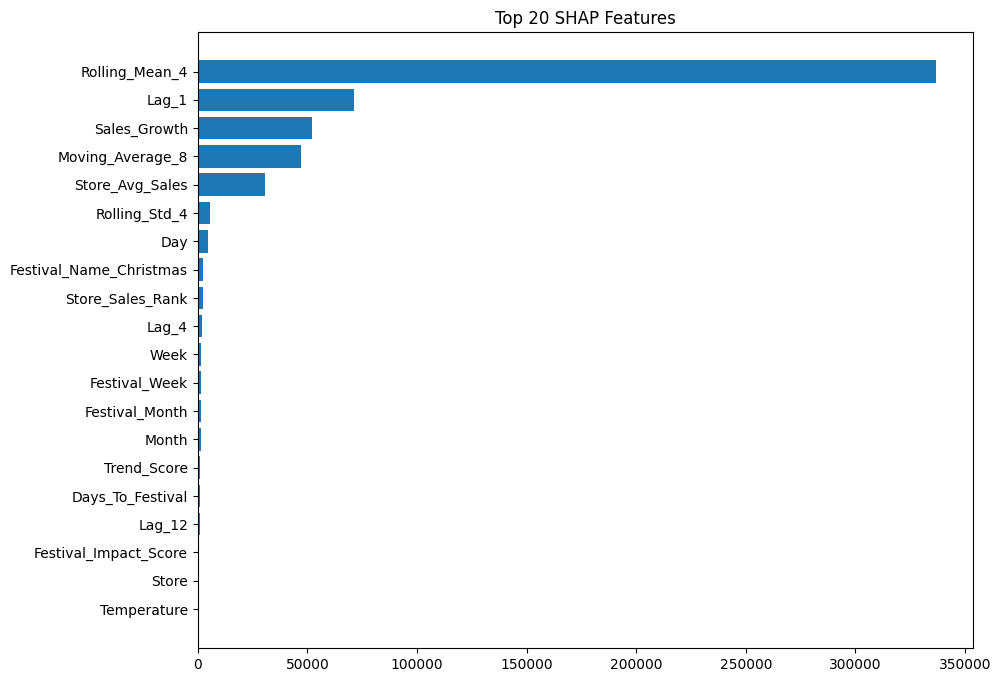

In [11]:
top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(

    top20["Feature"],

    top20["Importance"]

)

plt.title(
    "Top 20 SHAP Features"
)

plt.gca().invert_yaxis()

plt.show()

Festival Impact Analysis

In [12]:
festival_features = [

    col

    for col in X.columns

    if "Festival" in col

]

festival_features

['Festival_Flag',
 'Festival_Score',
 'Days_To_Festival',
 'Festival_Week',
 'Festival_Month',
 'Festival_Impact_Score',
 'Pre_Festival_Flag',
 'Post_Festival_Flag',
 'Festival_Trend',
 'Festival_Sentiment',
 'Festival_Name_Christmas',
 'Festival_Name_Diwali',
 'Festival_Name_Dussehra',
 'Festival_Name_Easter',
 'Festival_Name_Ganesh_Chaturthi',
 'Festival_Name_Halloween',
 'Festival_Name_Holi',
 'Festival_Name_Independence_Day',
 'Festival_Name_Janmashtami',
 'Festival_Name_Labor_Day',
 'Festival_Name_New_Year',
 'Festival_Name_Raksha_Bandhan',
 'Festival_Name_Valentines_Day']

SHAP Dependence Plot

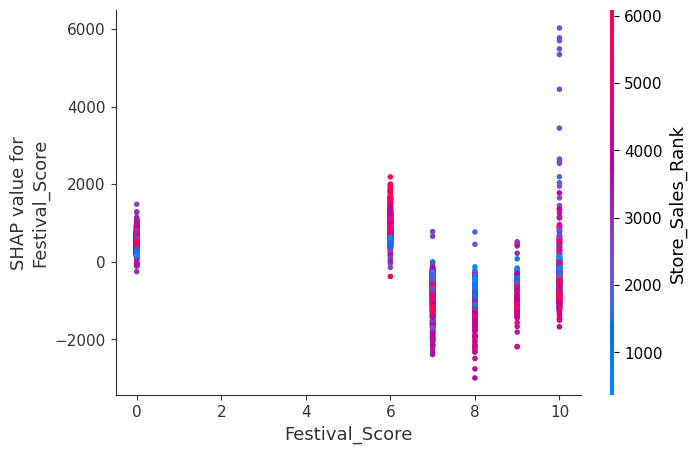

In [13]:
shap.dependence_plot(
    "Festival_Score",
    shap_values,
    X
)

Trend Score Impact

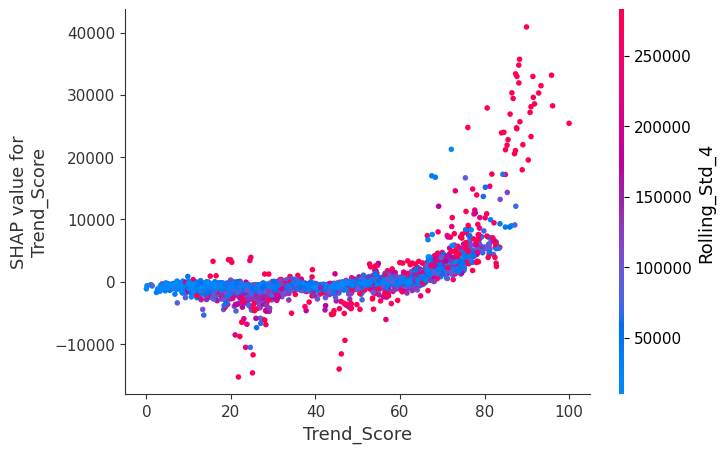

In [14]:
shap.dependence_plot(
    "Trend_Score",
    shap_values,
    X
)

Sentiment Impact

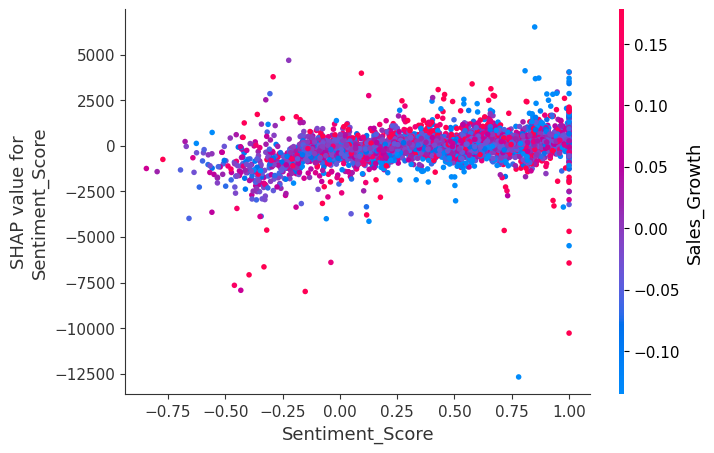

In [15]:
shap.dependence_plot(
    "Sentiment_Score",
    shap_values,
    X
)

Mention Count Impact

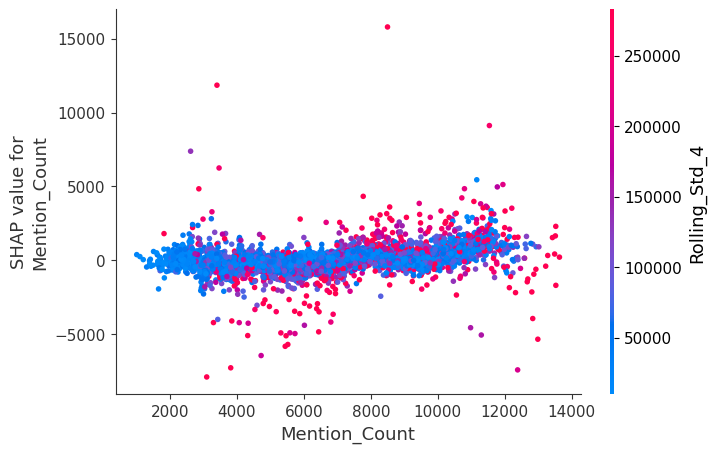

In [16]:
shap.dependence_plot(
    "Mention_Count",
    shap_values,
    X
)

Engagement Rate Impact

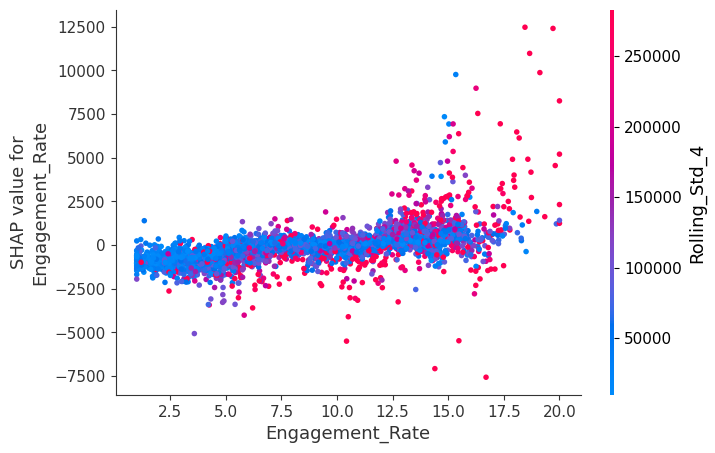

In [17]:
shap.dependence_plot(
    "Engagement_Rate",
    shap_values,
    X
)

Force Plot (Single Prediction)

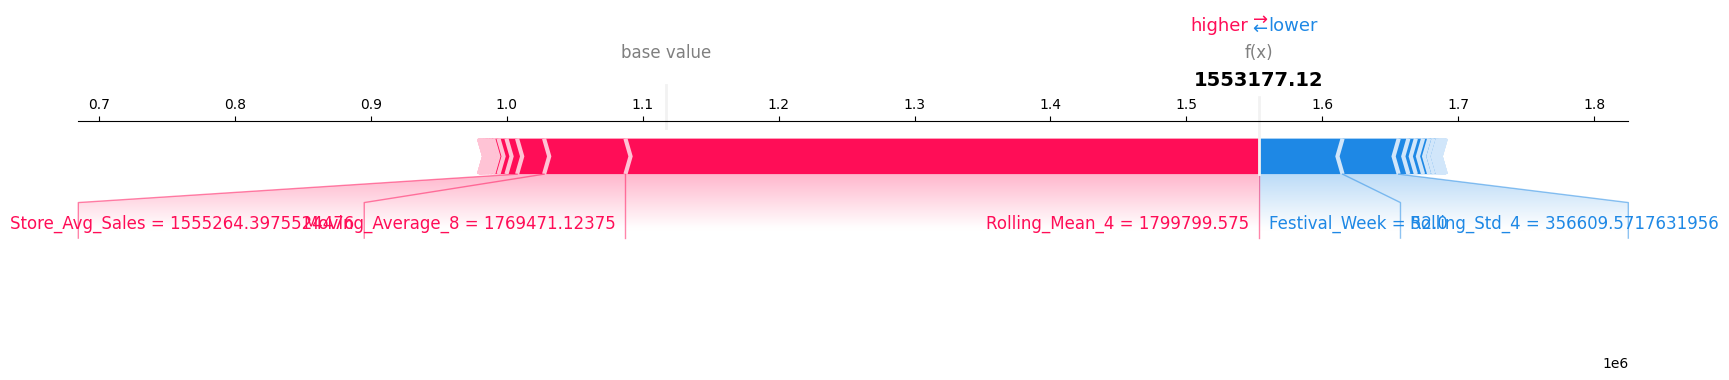

In [18]:
sample_index = 100

shap.force_plot(

    explainer.expected_value,

    shap_values[sample_index],

    X.iloc[sample_index],

    matplotlib=True
)

Waterfall Plot

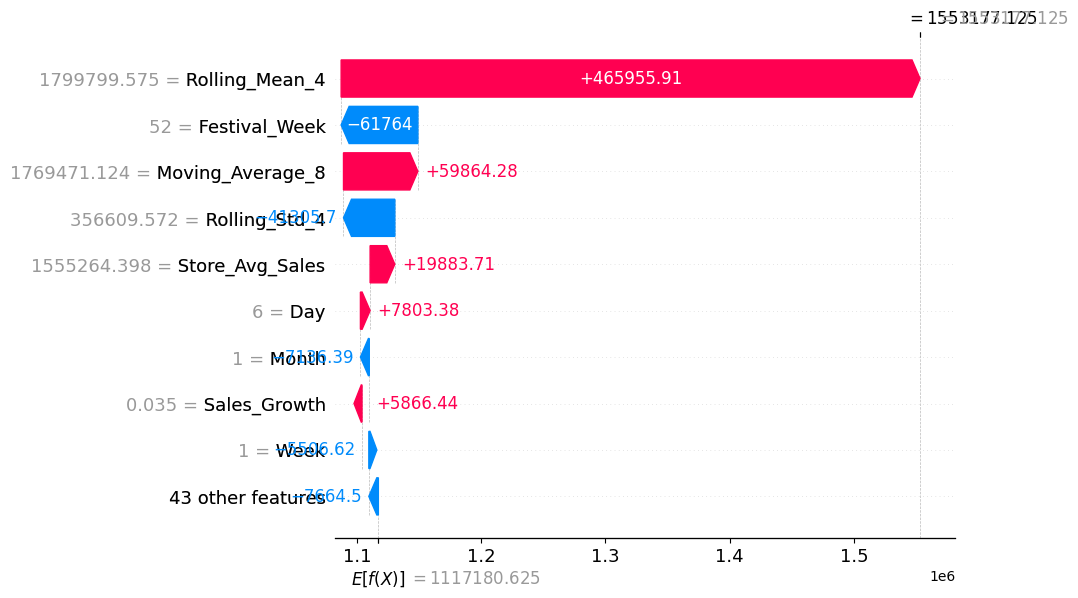

In [19]:
sample_index = 100

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[sample_index],

        base_values=explainer.expected_value,

        data=X.iloc[sample_index],

        feature_names=X.columns

    )

)

Save Feature Importance

In [20]:
importance.to_csv(

    "../outputs/shap_feature_importance.csv",

    index=False

)

print(
    "SHAP importance saved."
)

SHAP importance saved.


In [21]:
importance.head(10)

,Feature,Importance
30,Rolling_Mean_4,336698.843750
27,Lag_1,71234.218750
36,Sales_Growth,51929.601562
32,Moving_Average_8,47190.742188
37,Store_Avg_Sales,30580.281250
31,Rolling_Std_4,5708.929688
10,Day,4784.191895
39,Festival_Name_Christmas,2532.345459
38,Store_Sales_Rank,2220.090088
28,Lag_4,1770.846924
